# Red Neuronal Convolucional (CNN) - Clasificador de Animales
### PyTorch | Color RGB | 128×128 | RTX 3050 Laptop
### Clases: Arañas, Ballenas, Monos, Pájaros, Ranas — 10,000 imágenes por clase

**Estructura de carpetas requerida:**
```
dataset_animales/
├── aranas/    (10,000 imágenes)
├── ballenas/  (10,000 imágenes)
├── monos/     (10,000 imágenes)
├── pajaros/   (10,000 imágenes)
└── ranas/     (10,000 imágenes)
```

# 1. Instalar PyTorch con soporte GPU (CUDA 12.1)
> ▶️ Solo necesitas correr esto una vez. Omite si ya tienes PyTorch instalado.

In [27]:
# Instala PyTorch con soporte para RTX 3050 en Windows
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install scikit-learn matplotlib


Looking in indexes: https://download.pytorch.org/whl/cu121


# 2. Importar Librerías y Verificar GPU

In [28]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch version: {torch.__version__}')
if torch.cuda.is_available():
    print(f'✅ GPU detectada: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
else:
    print('⚠️  No se detectó GPU — se usará CPU (más lento)')
    print('   Instala PyTorch con: pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121')

print(f'\nUsando: {DEVICE}')


PyTorch version: 2.5.1+cu121
✅ GPU detectada: NVIDIA GeForce RTX 3050 Laptop GPU
   VRAM disponible: 4.0 GB

Usando: cuda


# 3. Configuración General

In [29]:
# ⚠️ Cambia DATASET_DIR a la ruta de tu carpeta dataset_animales
DATASET_DIR = r'C:\Users\bensa\Documents\ia\crear_dataset\Dataset_Final'
MODELO_PATH = 'mejor_modelo_animales.pth'

IMG_SIZE   = 128   #los pixeles a los que se va a renderizar las imagenes
BATCH_SIZE = 32    # Seguro para RTX 3050 de 4GB con imágenes 128x128 color
EPOCHS     = 50    # EarlyStopping detendrá antes si el modelo deja de mejorar
LR         = 0.0005  # 0.001 — valor estable para Adam
VAL_SPLIT  = 0.2 #toma el 20% del dataset para calarlo
CLASES     = ['aranas', 'ballenas', 'monos', 'pajaros', 'ranas']
PATIENCE   = 8     # Épocas sin mejorar antes de detener el entrenamiento

print('✅ Configuración cargada')
print(f'   Dataset:    {DATASET_DIR}')
print(f'   Imagen:     {IMG_SIZE}x{IMG_SIZE} px — Color RGB')
print(f'   Batch size: {BATCH_SIZE}')
print(f'   Épocas máx: {EPOCHS}')
print(f'   LR inicial: {LR}')
print(f'   Patience:   {PATIENCE} épocas')


✅ Configuración cargada
   Dataset:    C:\Users\bensa\Documents\ia\crear_dataset\Dataset_Final
   Imagen:     128x128 px — Color RGB
   Batch size: 32
   Épocas máx: 50
   LR inicial: 0.0005
   Patience:   8 épocas


# 4. Transformaciones e Data Augmentation
> Las transformaciones de entrenamiento agregan variaciones aleatorias para que el modelo no memorice las imágenes.
> Las de validación solo redimensionan y normalizan — sin cambios aleatorios.

In [30]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    # Normalización estándar ImageNet (funciona bien para cualquier dataset de imágenes naturales)
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), #después de que se alteraron las imagenes, se pasan a formato matematico para que la cosa aprenda
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]), #estandarizo los caolores para que el modelo arenda mejor, 
                         # aquí lo que hace es estandarizar un poco los valores de los pixeles, 
                         # para que el modelo aprenda mejor, ya que las imagenes pueden tener 
                         # diferentes iluminaciones, colores, etc. y esto ayuda a que el modelo aprenda mejor.
])

print('✅ Transformaciones configuradas')


✅ Transformaciones configuradas


# 5. Cargar Dataset y Verificar Equilibrio

=== DATASET ===
Total de imágenes : 50,000
Entrenamiento     : 40,000
Validación        : 10,000
Clases detectadas : ['aranas', 'ballenas', 'changos', 'pajaros', 'ranas']

=== EQUILIBRIO POR CLASE ===
  aranas    :  10000 imágenes  ████████████████████
  ballenas  :  10000 imágenes  ████████████████████
  changos   :  10000 imágenes  ████████████████████
  pajaros   :  10000 imágenes  ████████████████████
  ranas     :  10000 imágenes  ████████████████████

✅ Dataset BALANCEADO


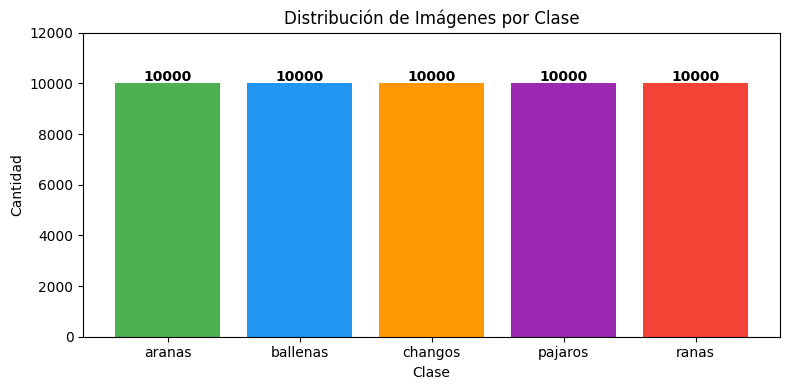

In [31]:
# Dataset completo con transformaciones de entrenamiento
dataset_completo = datasets.ImageFolder(DATASET_DIR, transform=train_transforms)

# Dividir en entrenamiento y validación
val_size   = int(len(dataset_completo) * VAL_SPLIT) #calculamos el length del set de validación con una multiplicación simple
train_size = len(dataset_completo) - val_size #calculamos con una resta el length del set de entrenamiento
train_ds, val_ds = random_split(dataset_completo, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(42))

# El set de validación usa sus propias transformaciones (sin augmentation)
val_dataset = datasets.ImageFolder(DATASET_DIR, transform=val_transforms)
val_ds.dataset = val_dataset

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('=== DATASET ===')
print(f'Total de imágenes : {len(dataset_completo):,}')
print(f'Entrenamiento     : {train_size:,}')
print(f'Validación        : {val_size:,}')
print(f'Clases detectadas : {dataset_completo.classes}')

# Verificar equilibrio por clase
print('\n=== EQUILIBRIO POR CLASE ===')
conteo = [0] * len(dataset_completo.classes)
for _, label in dataset_completo.samples:
    conteo[label] += 1
for clase, cantidad in zip(dataset_completo.classes, conteo):
    barra = '█' * (cantidad // 500)
    print(f'  {clase:<10}: {cantidad:>6} imágenes  {barra}')

min_c, max_c = min(conteo), max(conteo)
if max_c - min_c <= 100:
    print('\n✅ Dataset BALANCEADO')
else:
    print(f'\n⚠️  Dataset DESBALANCEADO (mín: {min_c}, máx: {max_c})')

# Gráfica de distribución
plt.figure(figsize=(8, 4))
colores = ['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336']
plt.bar(dataset_completo.classes, conteo, color=colores)
plt.title('Distribución de Imágenes por Clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.ylim(0, max(conteo) * 1.2)
for i, v in enumerate(conteo):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


# 6. Arquitectura del Modelo CNN
> 5 capas convolucionales + BatchNorm + Dropout para evitar sobreajuste

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_clases=5):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            # Capa 1: 3 → 32 filtros  | 128x128 → 64x64
            nn.Conv2d(3, 32, kernel_size=3, padding=1), #escanea la imagen buscando patrones 
            nn.BatchNorm2d(32), #estabiliza el aprendizaje numerico
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1),

            #cuantos feature maps se ando entregando de la capa anterior y cuantos filtros se van a usar en esta capa
            # Capa 2: 32 → 64 filtros  | 64x64 → 32x32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1),

            # Capa 3: 64 → 128 filtros | 32x32 → 16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),

            # Capa 4: 128 → 256 filtros | 16x16 → 8x8
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),

            # Capa 5: 256 → 256 filtros | 8x8 → 4x4
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                        # 256 * 4 * 4 = 4096
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_clases),
        )
    #la sinta transportadora el resultado de las capas convolucionales
    #  a las capas lineales para que se pueda hacer la clasificación final
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

#creo el modelo 
modelo = CNN(num_clases=len(dataset_completo.classes)).to(DEVICE)
print(modelo)

#cada peso y sesgo 
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'\nParámetros entrenables: {total_params:,}')

# Estimar uso de VRAM
param_mb = total_params * 4 / 1024**2 #para que no explote mi lap
print(f'Memoria aprox del modelo: {param_mb:.1f} MB')


CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.1, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.1, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout2d(p=0.2, inplace=False)
    (15): Co

# 7. Funciones de Entrenamiento y Validación

In [ ]:
criterio    = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo.parameters(), lr=LR)

# ReduceLROnPlateau: baja el LR a la mitad si val_loss no mejora en 3 épocas
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizador, mode='min', factor=0.5, patience=3, min_lr=1e-7, verbose=True
)

def entrenar_epoch(modelo, loader, criterio, optimizador):
    modelo.train() #activo el modo train, para que apague neuronas aleatoriamente y haga el backpropagation, para que el modelo aprenda mejor
    loss_total, correctos, total = 0, 0, 0
    for imgs, etiquetas in loader: #repota el lote de imagenes y etiquetas del dataloader
        imgs, etiquetas = imgs.to(DEVICE), etiquetas.to(DEVICE) #manda las imagenes y etiquetas a la GPU para que el entrenamiento sea más rápido
        optimizador.zero_grad() #cada iteracion se limpia el gradiente para que no se acumulen los gradientes de las iteraciones anteriores
        
        # --- ¡AQUÍ OCURRE EL FORWARD PASS! ---
        salidas = modelo(imgs) #el modelo procesa las imagenes y devuelve las salidas (predicciones sin procesar)
        
        # 2. Calcula el error
        loss = criterio(salidas, etiquetas)#checa si le atino a las etiquetas, y si no le atino, le da un valor de
                                            #error (loss) que es lo que el modelo va a tratar de minimizar
        
        # --- ¡AQUÍ OCURRE EL BACKWARD PASS! ---
        loss.backward() #ve que neurona es la culpable para que aprenda mejor
        
        # 3. Actualiza los pesos
        optimizador.step() #ajusta todo para un futuro mejor
        loss_total += loss.item()
        _, predicciones = torch.max(salidas, 1)
        correctos += (predicciones == etiquetas).sum().item()
        total += etiquetas.size(0)
    return loss_total / len(loader), correctos / total


def validar_epoch(modelo, loader, criterio):
    modelo.eval() #ya ahora el modelo no apaga neuronas aleatoriamente ni hace backpropagation, solo hace la inferencia para evaluar el rendimiento del modelo
    loss_total, correctos, total = 0, 0, 0
    with torch.no_grad(): #le decimos que de estas imagenes no va aprender nada
        for imgs, etiquetas in loader:
            imgs, etiquetas = imgs.to(DEVICE), etiquetas.to(DEVICE)
            salidas = modelo(imgs)
            loss = criterio(salidas, etiquetas)
            loss_total += loss.item()
            _, predicciones = torch.max(salidas, 1)
            correctos += (predicciones == etiquetas).sum().item()
            total += etiquetas.size(0)
    return loss_total / len(loader), correctos / total

print('✅ Funciones de entrenamiento listas')


✅ Funciones de entrenamiento listas


c:\Users\bensa\Documents\ia\crear_dataset\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


# 8. Entrenamiento con EarlyStopping
> ⏳ Con RTX 3050 laptop debería tardar entre **1 y 2 horas** dependiendo de cuántas épocas alcance antes del EarlyStopping

In [34]:
historial = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

mejor_val_acc  = 0.0
epocas_sin_mejora = 0

print('Iniciando entrenamiento...\n')
print(f"{'Época':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} Estado")
print('-' * 70)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = entrenar_epoch(modelo, train_loader, criterio, optimizador)
    val_loss,   val_acc   = validar_epoch(modelo, val_loader,   criterio)

    scheduler.step(val_loss)

    historial['train_loss'].append(train_loss)
    historial['val_loss'].append(val_loss)
    historial['train_acc'].append(train_acc)
    historial['val_acc'].append(val_acc)

    # Guardar si es el mejor modelo
    if val_acc > mejor_val_acc:
        mejor_val_acc = val_acc
        epocas_sin_mejora = 0
        torch.save(modelo.state_dict(), MODELO_PATH)
        estado = '✓ guardado'
    else:
        epocas_sin_mejora += 1
        estado = f'sin mejora ({epocas_sin_mejora}/{PATIENCE})'

    print(f'{epoch:02d}/{EPOCHS:<5} {train_loss:<12.4f} {train_acc*100:<12.1f} {val_loss:<12.4f} {val_acc*100:<12.1f} {estado}')

    # EarlyStopping
    if epocas_sin_mejora >= PATIENCE:
        print(f'\n🛑 EarlyStopping: {PATIENCE} épocas sin mejorar. Entrenamiento detenido.')
        break

print(f'\n✅ Entrenamiento finalizado en {epoch} épocas')
print(f'   Mejor val_acc: {mejor_val_acc*100:.1f}%')
print(f'   Modelo guardado en: {MODELO_PATH}')


Iniciando entrenamiento...

Época    Train Loss   Train Acc    Val Loss     Val Acc      Estado
----------------------------------------------------------------------
01/50    0.6072       76.5         0.3101       89.6         ✓ guardado
02/50    0.3550       87.0         0.1967       93.3         ✓ guardado
03/50    0.2714       90.3         0.1593       94.4         ✓ guardado
04/50    0.2139       92.5         0.1450       94.8         ✓ guardado
05/50    0.1842       93.5         0.0965       96.8         ✓ guardado
06/50    0.1617       94.5         0.0846       97.2         ✓ guardado
07/50    0.1420       95.3         0.0937       96.6         sin mejora (1/8)
08/50    0.1280       95.7         0.0708       97.4         ✓ guardado
09/50    0.1179       96.1         0.0562       98.0         ✓ guardado
10/50    0.1062       96.5         0.0645       97.8         sin mejora (1/8)
11/50    0.0954       96.8         0.0589       98.0         ✓ guardado
12/50    0.0872       97.2   

# 9. Gráficas de Entrenamiento

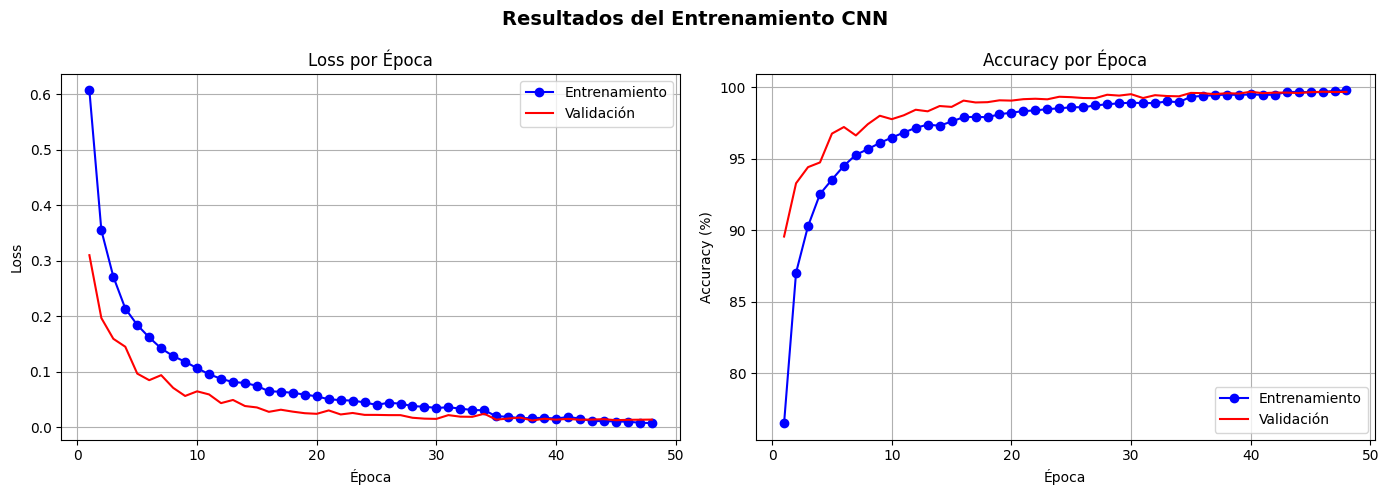

Gráfica guardada en entrenamiento.png
✅ Buena generalización: diferencia train/val = 0.1%


In [35]:
epocas_rango = range(1, len(historial['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epocas_rango, historial['train_loss'], 'bo-', label='Entrenamiento')
ax1.plot(epocas_rango, historial['val_loss'],   'r-',  label='Validación')
ax1.set_title('Loss por Época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epocas_rango, [a*100 for a in historial['train_acc']], 'bo-', label='Entrenamiento')
ax2.plot(epocas_rango, [a*100 for a in historial['val_acc']],   'r-',  label='Validación')
ax2.set_title('Accuracy por Época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Resultados del Entrenamiento CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('entrenamiento.png', dpi=150)
plt.show()
print('Gráfica guardada en entrenamiento.png')

# Diagnóstico de sobreajuste
diferencia = max(historial['train_acc']) - max(historial['val_acc'])
if diferencia > 0.1:
    print(f'⚠️  Posible sobreajuste: diferencia train/val = {diferencia*100:.1f}%')
else:
    print(f'✅ Buena generalización: diferencia train/val = {diferencia*100:.1f}%')


# 10. Evaluación Final y Reporte de Clasificación

In [36]:
# Cargar el mejor modelo guardado
modelo.load_state_dict(torch.load(MODELO_PATH))
modelo.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for imgs, etiquetas in val_loader:
        imgs = imgs.to(DEVICE)
        salidas = modelo(imgs)
        _, predicciones = torch.max(salidas, 1)
        y_true.extend(etiquetas.numpy())
        y_pred.extend(predicciones.cpu().numpy())

print('=== REPORTE DE CLASIFICACIÓN ===')
print(classification_report(y_true, y_pred, target_names=dataset_completo.classes))


C:\Users\bensa\AppData\Local\Temp\ipykernel_21500\1899275789.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelo.load_state_dict(torch.load(MODELO_PATH))


=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

      aranas       0.99      0.99      0.99      1986
    ballenas       1.00      1.00      1.00      2035
     changos       1.00      0.99      1.00      1967
     pajaros       1.00      1.00      1.00      1950
       ranas       0.99      1.00      0.99      2062

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



# 11. Matriz de Confusión
> Muestra exactamente qué clases confunde el modelo entre sí.
> Los números en la diagonal son aciertos; fuera de ella son errores.

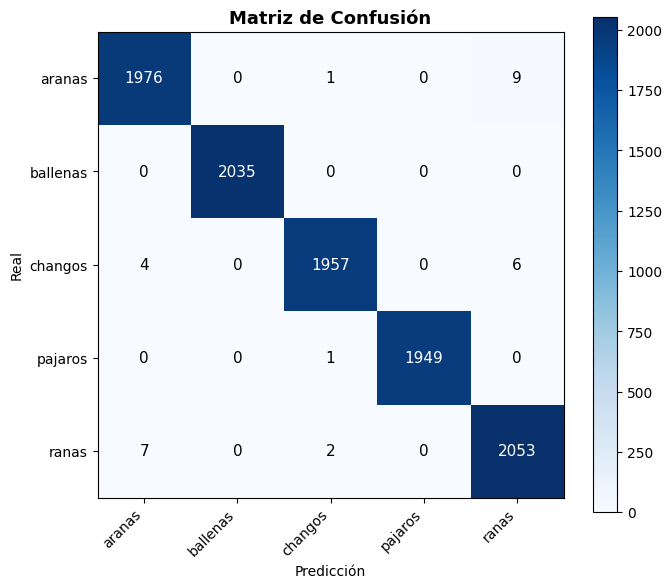

Matriz guardada en confusion_matrix.png


In [37]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(dataset_completo.classes)))
ax.set_yticks(range(len(dataset_completo.classes)))
ax.set_xticklabels(dataset_completo.classes, rotation=45, ha='right')
ax.set_yticklabels(dataset_completo.classes)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=11)
ax.set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Matriz guardada en confusion_matrix.png')


---
# ════════════════════════════════════════
# 🔄 DESDE AQUÍ PUEDES EMPEZAR SIN REENTRENAR
# ════════════════════════════════════════
### Si reinicias el kernel, ejecuta solo las celdas 12 y 13

# 12. Cargar Modelo Guardado
### ▶️ Ejecuta esta celda PRIMERO si reinicias el kernel

In [1]:
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision import datasets

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODELO_PATH = 'mejor_modelo_animales.pth'
IMG_SIZE    = 128
CLASES      = ['aranas', 'ballenas', 'monos', 'pajaros', 'ranas']

# Redefinir el modelo (necesario para cargar los pesos)
class CNN(nn.Module):
    def __init__(self, num_clases=5):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            #aquí cargamos el cuerpo, porque le vamos a implamantor los recuerdos
            #primero los RGB
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2), nn.Dropout2d(0.1),
            #ya luego las profundiddasdes que vamos sacando más patrones complejos
            nn.Conv2d(32, 64, kernel_size=3 , padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2), nn.Dropout2d(0.1),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), #aplana los datos para poder pasarlos a las capas lineales
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(inplace=True), nn.Dropout(0.4), #aquí se conecta el cuerpo con la cabeza, es decir, 
            #se conectan las capas convolucionales con las capas lineales para que el modelo pueda hacer la clasificación final 
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(0.3), 
            nn.Linear(128, num_clases),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

modelo = CNN(num_clases=len(CLASES)).to(DEVICE)
modelo.load_state_dict(torch.load(MODELO_PATH, map_location=DEVICE))
modelo.eval()

print(f'✅ Modelo cargado correctamente')
print(f'   Usando: {DEVICE}')
print(f'   Clases: {CLASES}')
print('\n▶️ Listo — ejecuta la celda 13 para identificar un animal')


✅ Modelo cargado correctamente
   Usando: cuda
   Clases: ['aranas', 'ballenas', 'monos', 'pajaros', 'ranas']

▶️ Listo — ejecuta la celda 13 para identificar un animal


C:\Users\bensa\AppData\Local\Temp\ipykernel_9408\806086619.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelo.load_state_dict(torch.load(MODELO_PATH, map_location=D

# 13. 🔍 Identificar una Imagen Nueva
### ▶️ Ejecuta esta celda cada vez que quieras identificar un animal

📂 Imagen seleccionada: C:/Users/bensa/Downloads/arana5.jpg


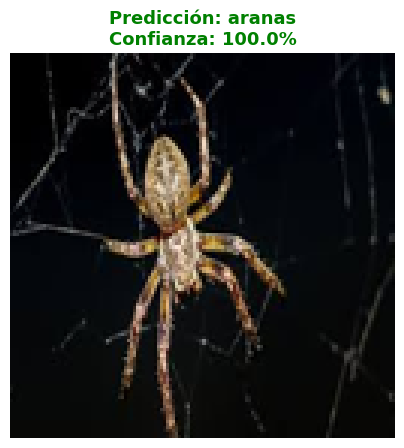


🐾 Animal identificado: ARANAS
   Confianza: 100.0%
   ⚠️  Confianza muy alta — verifica que la imagen sea similar al dataset

   Probabilidades por clase:
   aranas    : 100.0%  ██████████████████████████████
   ballenas  :   0.0%  
   monos     :   0.0%  
   pajaros   :   0.0%  
   ranas     :   0.0%  


In [23]:
import tkinter as tk
from tkinter import filedialog
from torchvision import transforms
from PIL import Image

# Transformación para la imagen nueva (igual que validación)
predict_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Abrir selector de archivo
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)
mi_imagen = filedialog.askopenfilename(
    title='Selecciona una imagen de animal',
    filetypes=[('Imágenes', '*.jpg *.jpeg *.png *.bmp *.tiff'), ('Todos', '*.*')]
)
root.destroy()

if not mi_imagen:
    print('⚠️  No seleccionaste ninguna imagen.')
else:
    print(f'📂 Imagen seleccionada: {mi_imagen}')

    img_pil = Image.open(mi_imagen).convert('RGB')
    img_tensor = predict_transform(img_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        salidas    = modelo(img_tensor)
        probs      = torch.softmax(salidas, dim=1)[0]
        clase_idx  = torch.argmax(probs).item()
        confianza  = probs[clase_idx].item() * 100

    # Mostrar resultado
    plt.figure(figsize=(5, 5))
    plt.imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    color = 'green' if confianza >= 60 else 'orange' if confianza >= 40 else 'red'
    plt.title(
        f'Predicción: {CLASES[clase_idx]}\nConfianza: {confianza:.1f}%',
        fontsize=13, fontweight='bold', color=color
    )
    plt.axis('off')
    plt.show()

    print(f'\n🐾 Animal identificado: {CLASES[clase_idx].upper()}')
    print(f'   Confianza: {confianza:.1f}%')
    if confianza > 99.0:
        print('   ⚠️  Confianza muy alta — verifica que la imagen sea similar al dataset')

    print('\n   Probabilidades por clase:')
    for clase, prob in zip(CLASES, probs):
        barra = '█' * int(prob.item() * 30)
        print(f'   {clase:<10}: {prob.item()*100:5.1f}%  {barra}')
